# 03 — MIDAS (weekly target, weekly controls + monthly macro)

This notebook is the weekly-frequency MIDAS benchmark. It forecasts W-FRI silver returns using weekly AR/cross-asset/public-info controls plus monthly macro variables aligned by publication availability.

### Roadmap

| § | Step | What happens |
|---|---|---|
| 0 | Model intuition | Weekly controls $z_t$ enter as a plain regression block; each monthly macro series is collapsed to one weighted feature via its own lag-weight curve. |
| 1 | Load + aggregate | Read raw daily/monthly data and aggregate to the W-FRI weekly target and controls. |
| 2 | Weekly base controls | Build the `EXOG` base — silver AR lags + 6 cross-asset weekly returns. |
| 3 | Monthly macro block | Build the publication-availability-lagged macro lag matrices (`cpi, fed_funds, ind_prod, m2`, 3 lags each) + a look-ahead audit. |
| 4 | Weekly sentiment controls | Lagged Reddit / News sentiment, used only inside the macro rungs. |
| 5 | MIDAS weight functions | Beta / exp-Almon lag-weight curves (U-MIDAS = one free coefficient per lag). |
| 6 | MIDAS estimators | NLS `fit_with_midas` + U-MIDAS / OLS fitters, generic over a list of lag matrices. |
| 7 | Two-stage protocol | **Stage 1**: pick the weight family on validation WDA. **Stage 2**: freeze it, walk forward (expanding + rolling-100w, refit every 4w) over the ladder — `EXOG` base + the MIDAS-macro rungs. |
| 8 | Results table | RMSE / MAE / OOS R² / DA / WDA for Naive, Drift, EXOG, every MIDAS rung. Save `metrics_midas.csv`. |
| 9 | Period breakdown | Drift floor + WDA-best + RMSE-best per `PERIODS`; save period + preds CSVs. |
| 10 | Significance tests | Load-bearing DM vs-Drift floor (OOS R² + DM, squared & absolute error); Pesaran–Timmermann directional lens. |
| 11 | Robustness — ex-2025 | Re-run the battery on 2023 + 2024 + 2026 only. |
| 12 | 2026 zoom | WDA-best and RMSE-best vs the drift floor on the 2026 YTD slice. |
| 13 | Lag-weight profiles | The MIDAS analogue of feature importance — the fitted lag-weight curve per macro variable. |

## 0. Model intuition

Let $y_t$ be the weekly silver return for forecast week $t$. The ordinary weekly controls enter as a standard regression block $z_t$, while each monthly macro series $x_j$ enters through its own lag path:

$$
X_{j,t} = (x_{j,t-1}^{avail}, x_{j,t-2}^{avail}, x_{j,t-3}^{avail}).
$$

Restricted MIDAS replaces those raw lag columns with one weighted feature per macro variable:

$$
\tilde{x}_{j,t}(\theta_j) = \sum_{k=1}^{K} w_{j,k}(\theta_j) x_{j,t-k}^{avail}, \quad \sum_k w_{j,k}=1.
$$

Each macro variable gets its own lag-weight curve. Conditional on the weights, the regression is just OLS; the nonlinear optimizer only searches over the weight-shape parameters. Because monthly $K=3$ is small, this notebook also keeps U-MIDAS as a candidate/ablation, where every monthly lag receives its own OLS coefficient.


## Setup

*Imports the numerical stack, plotting tools, and shared evaluation helpers.*


In [ ]:
import sys, os
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
sys.path.append('../../../src')
from eval_utils import evaluate, period_metrics, diebold_mariano, pesaran_timmermann, oos_r2, PERIODS

DATA = '../../../data/processed/'
RAW  = '../../../data/raw/'


## 1. Load and Aggregate to Weekly

*Loads train/validation/test splits and builds the W-FRI weekly frame. Daily-origin returns and FRED changes are collapsed to weekly controls here; they are not used as high-frequency MIDAS blocks in this notebook.*


In [ ]:
train = pd.read_csv(DATA+'train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv(DATA+'val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv(DATA+'test.csv',  index_col=0, parse_dates=True)

TARGET = 'silver_return'
CROSS_ASSET_RETURN_VARS = ['gold_return','usd_return','copper_return','sp500_return','vix_return','oil_return']
EXOG_LEVELS = ['gs_ratio_z']
FRED_WEEKLY_CHG_VARS = ['real_rates_chg','breakeven_chg','jobless_chg']
COT_COLS = ['cot_mm_net_pct','cot_comm_net_pct']

# This notebook is weekly-frequency MIDAS: the target and non-macro controls are
# first aggregated to W-FRI weeks. Daily-origin returns/changes are not used as
# high-frequency MIDAS blocks here; they become ordinary one-week-lag controls.
def to_weekly(df):
    # Returns and change variables add over the week. `jobless_chg` is a log-change
    # series on the daily grid, so summing the mostly-zero daily rows recovers the
    # weekly change used by the ARIMA/VAR public-info controls.
    summ = [c for c in [TARGET] + CROSS_ASSET_RETURN_VARS + FRED_WEEKLY_CHG_VARS if c in df.columns]

    # GS ratio and COT positioning are state/snapshot variables, so the weekly value
    # is the latest snapshot inside the W-FRI bucket.
    last = [c for c in EXOG_LEVELS + COT_COLS + ['china_pmi_proxy'] if c in df.columns]

    agg = {c: 'sum' for c in summ}
    agg.update({c: 'last' for c in last})
    return df.resample('W-FRI').agg(agg)

train_w, val_w, test_w = to_weekly(train), to_weekly(val), to_weekly(test)
all_weekly = pd.concat([train_w, val_w, test_w]).sort_index()
n_train = len(train_w) + len(val_w)
print(f'Weekly obs — train+val: {n_train}, test: {len(test_w)}')


Weekly obs — train+val: 417, test: 174


## 2. Weekly Base Controls

*Builds the weekly AR/cross-asset/public-info controls used as ordinary regression regressors.*


In [ ]:
# Silver autoregressive controls: the same weekly AR backbone used in the other weekly models.
for k in (1, 2, 3):
    all_weekly[f'silver_lag{k}'] = all_weekly['silver_return'].shift(k)

# Cross-asset controls are weekly lags here. The daily return columns were summed
# to weekly returns in `to_weekly`; this is not the daily/HF MIDAS block from 03b.
for v in CROSS_ASSET_RETURN_VARS:
    all_weekly[v.replace('_return', '_lag1')] = all_weekly[v].shift(1)

# Weekly lag of the gold/silver ratio state.
for v in EXOG_LEVELS:
    all_weekly[f'{v}_lag1'] = all_weekly[v].shift(1)

# Public-info controls: one-week lag, with warm-up zeros matching the ARIMA/VAR notebooks.
for v in FRED_WEEKLY_CHG_VARS + COT_COLS:
    if v in all_weekly.columns:
        all_weekly[f'{v}_lag1'] = all_weekly[v].shift(1).fillna(0.0)

EXOG_LAGS = [c for c in [
    'silver_lag1','silver_lag2','silver_lag3',
    'gold_lag1','usd_lag1','copper_lag1','sp500_lag1','vix_lag1','oil_lag1'
] if c in all_weekly.columns]
GS_LAGS = [f'{v}_lag1' for v in EXOG_LEVELS if f'{v}_lag1' in all_weekly.columns]
FRED_LAGS = [f'{v}_lag1' for v in FRED_WEEKLY_CHG_VARS if f'{v}_lag1' in all_weekly.columns]
COT_LAGS = [f'{v}_lag1' for v in COT_COLS if f'{v}_lag1' in all_weekly.columns]
# China PMI proxy: point-in-time level -> one-week lag (a daily-macro-style control, not a MIDAS block).
if 'china_pmi_proxy' in all_weekly.columns:
    all_weekly['china_pmi_proxy_lag1'] = all_weekly['china_pmi_proxy'].shift(1).fillna(0.0)
PMI_LAGS = [c for c in ['china_pmi_proxy_lag1'] if c in all_weekly.columns]
print('EXOG:', EXOG_LAGS)
print('GS:', GS_LAGS, '| FRED weekly-change:', FRED_LAGS, '| COT:', COT_LAGS, '| PMI:', PMI_LAGS)


EXOG: ['silver_lag1', 'silver_lag2', 'silver_lag3', 'gold_lag1', 'usd_lag1', 'copper_lag1', 'sp500_lag1', 'vix_lag1', 'oil_lag1']
GS: ['gs_ratio_z_lag1'] | FRED weekly-change: ['real_rates_chg_lag1', 'breakeven_chg_lag1', 'jobless_chg_lag1'] | COT: ['cot_mm_net_pct_lag1', 'cot_comm_net_pct_lag1'] | PMI: ['china_pmi_proxy_lag1']


## 3. Monthly Macro MIDAS Block

*Constructs weekly-aligned monthly macro lag matrices. The raw macro series are monthly, but each weekly forecast row still needs the latest publication-available monthly releases.*


In [ ]:
macro = pd.read_csv(RAW+'monthly_macro.csv', index_col=0, parse_dates=True)
MACRO_VARS = ['cpi','fed_funds','ind_prod','m2']
assert all(v in macro.columns for v in MACRO_VARS), 'monthly_macro.csv missing a column'

# Three monthly releases: roughly one quarter of macro memory. U-MIDAS is feasible
# here because the monthly lag block is tiny; it would not be feasible for 20 daily lags.
N_MACRO_LAGS = 3

# Approximate publication delays from the month stamp to when each release becomes public.
MACRO_AVAIL_LAG = {'cpi':46, 'ind_prod':48, 'fed_funds':35, 'm2':30}

def build_monthly_midas_matrix(weekly_dates, monthly_series, release_lag_days, n_lags=N_MACRO_LAGS):
    """
    Build one monthly-to-weekly MIDAS lag matrix.

    For each weekly Friday target, the row contains the newest monthly releases that
    would have been public before the forecast week began. Column 0 is the newest
    available release (`mlag_1`), and the final column is the oldest release.
    """
    monthly_values = monthly_series.to_numpy()
    observed = np.isfinite(monthly_values)
    available_dates = monthly_series.index + pd.Timedelta(days=release_lag_days)
    lag_matrix = np.full((len(weekly_dates), n_lags), np.nan)

    for row, week_end in enumerate(weekly_dates):
        # W-FRI target weeks are labelled by Friday. Friday - 6 days is the Saturday
        # before the target week, so '< cutoff' excludes the target week's information.
        public_info_cutoff = week_end - pd.Timedelta(days=6)
        usable_history = observed & (available_dates < public_info_cutoff)
        usable_values = monthly_values[usable_history]

        if len(usable_values) >= n_lags:
            lag_matrix[row] = usable_values[-n_lags:][::-1]

    return lag_matrix

macro_lags = {}
for var in MACRO_VARS:
    macro_lags[var] = build_monthly_midas_matrix(
        all_weekly.index,
        macro[var],
        MACRO_AVAIL_LAG[var],
    )

print('Macro lag matrices:', {v: m.shape for v, m in macro_lags.items()})


Macro lag matrices: {'cpi': (591, 3), 'fed_funds': (591, 3), 'ind_prod': (591, 3), 'm2': (591, 3)}


### Look-Ahead Audit — Macro

*Checks that the monthly macro matrices only use releases available before the target week starts.*


In [ ]:
position_fri = all_weekly.index - pd.Timedelta(days=7)
for v in MACRO_VARS:
    available_dates = macro.index + pd.Timedelta(days=MACRO_AVAIL_LAG[v])
    observed = macro[v].notna().to_numpy()
    min_slack = np.inf

    for i, week_end in enumerate(all_weekly.index):
        cutoff = week_end - pd.Timedelta(days=6)
        usable = observed & (available_dates < cutoff)
        if usable.any():
            min_slack = min(min_slack, (position_fri[i] - available_dates[usable].max()).days)

    assert not (np.isfinite(min_slack) and min_slack < 0), f'look-ahead in {v}'
    print(f'  {v:11s} OK  (min slack {int(min_slack)} d)')
print('Macro look-ahead audit passed.')


  cpi         OK  (min slack 0 d)
  fed_funds   OK  (min slack 0 d)
  ind_prod    OK  (min slack 0 d)
  m2          OK  (min slack 0 d)
Macro look-ahead audit passed.


## 4. Weekly Sentiment Controls

*Aggregates daily sentiment to weekly averages, forward-fills latest known sentiment, and lags one week.*


In [ ]:
sent = pd.read_csv(DATA+'daily_sentiment.csv', index_col=0, parse_dates=True)
sent_cols = [c for c in ['reddit_sentiment','news_sentiment','news_paid_sentiment_title'] if c in sent.columns]
aligned = sent[sent_cols].resample('W-FRI').mean().reindex(all_weekly.index)

# Sentiment is kept as a weekly control in this notebook. We average daily sentiment
# inside the W-FRI bucket, carry the latest observed tone forward, then lag one week.
SENT_LAGS = []
if 'reddit_sentiment' in sent_cols:
    all_weekly['reddit_lag1'] = aligned['reddit_sentiment'].ffill().shift(1).fillna(0.0)
    SENT_LAGS.append('reddit_lag1')
if 'news_sentiment' in sent_cols:
    all_weekly['news_lag1'] = aligned['news_sentiment'].ffill().shift(1).fillna(0.0)
    SENT_LAGS.append('news_lag1')

# Paid-news title — a separate weekly control (paid twin of news_lag1); NOT added to SENT_LAGS.
news_paid_available = 'news_paid_sentiment_title' in sent_cols
if news_paid_available:
    all_weekly['news_paid_lag1'] = aligned['news_paid_sentiment_title'].ffill().shift(1).fillna(0.0)

sentiment_available = len(SENT_LAGS) > 0
print('Sentiment merged:', SENT_LAGS, '| paid-news:', news_paid_available)


Sentiment merged: ['reddit_lag1', 'news_lag1'] | paid-news: True


## 5. MIDAS Weight Functions

*Defines the restricted Beta and exponential-Almon lag-weight curves. Both normalize weights to sum to one.*


In [ ]:
def nbeta_w(k, theta):
    th = np.maximum(theta, 0.1)
    x  = k / (k.max() + 1)
    w  = x**(th[0]-1) * (1-x)**(th[1]-1)
    w  = np.maximum(w, 1e-10)
    return w / w.sum()

def nealmon_w(k, theta):
    e = theta[0]*k + theta[1]*k**2
    e = e - e.max()
    w = np.exp(e)
    return w / w.sum()


## 6. MIDAS Estimators

*Implements restricted MIDAS and U-MIDAS from scratch. Restricted MIDAS learns one two-parameter weight curve per macro variable and then solves the linear coefficients by OLS; U-MIDAS keeps each monthly lag as an ordinary OLS regressor.*


In [ ]:
def fit_with_midas(y, base_X, midas_mats, weight_fn=nbeta_w, start=None, lower=None):
    """
    Fit restricted MIDAS by nonlinear least squares.

    `base_X` contains ordinary weekly regressors. Each matrix in `midas_mats` is
    compressed into one weighted column using its own two-parameter lag-weight curve.
    Conditional on those weights, the regression coefficients are solved by OLS.
    """
    names = list(midas_mats)
    n_midas = len(names)
    lag_numbers = {v: np.arange(1, midas_mats[v].shape[1] + 1) for v in names}
    if start is None:
        start = np.tile([1.0, 5.0], n_midas)
    if lower is None:
        lower = np.full(2 * n_midas, 0.1)

    base = np.asarray(base_X, float)
    y = np.asarray(y, float)

    def design(theta):
        weighted_cols = []
        for j, name in enumerate(names):
            theta_j = theta[2*j:2*j+2]
            weights_j = weight_fn(lag_numbers[name], theta_j)
            weighted_cols.append(midas_mats[name] @ weights_j)
        return np.column_stack([np.ones(len(y)), base, np.column_stack(weighted_cols)])

    def obj(theta):
        X = design(theta)
        if not np.all(np.isfinite(X)):
            return 1e9
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        resid = y - X @ beta
        return float(resid @ resid)

    res = minimize(
        obj,
        start,
        method='L-BFGS-B',
        bounds=[(lo, None) for lo in lower],
        options={'maxiter': 1000},
    )

    theta = res.x
    weights = {}
    for j, name in enumerate(names):
        weights[name] = weight_fn(lag_numbers[name], theta[2*j:2*j+2])

    X = design(theta)
    coefs, *_ = np.linalg.lstsq(X, y, rcond=None)
    return {
        'spec': 'restricted',
        'weights': weights,
        'coefs': coefs,
        'theta': theta,
        'names': names,
        'converged': bool(res.success),
    }

def predict_with_midas(fit, base_X, midas_mats):
    """Apply stored restricted-MIDAS weights and linear coefficients to new rows."""
    base = np.asarray(base_X, float)
    weighted_cols = [midas_mats[v] @ fit['weights'][v] for v in fit['names']]
    X = np.column_stack([np.ones(len(base)), base, np.column_stack(weighted_cols)])
    return X @ fit['coefs']

def fit_umidas(y, base_X, midas_mats):
    """U-MIDAS: keep each monthly lag as its own OLS coefficient."""
    names = list(midas_mats)
    lag_block = np.column_stack([midas_mats[v] for v in names])
    X = np.column_stack([np.ones(len(y)), np.asarray(base_X, float), lag_block])
    coefs, *_ = np.linalg.lstsq(X, np.asarray(y, float), rcond=None)
    return {'spec': 'umidas', 'coefs': coefs, 'names': names, 'ncols': {v: midas_mats[v].shape[1] for v in names}}

def predict_umidas(fit, base_X, midas_mats):
    lag_block = np.column_stack([midas_mats[v] for v in fit['names']])
    X = np.column_stack([np.ones(len(np.asarray(base_X))), np.asarray(base_X, float), lag_block])
    return X @ fit['coefs']

def make_mask(y, base_X, midas_mats):
    """Rows are usable only when y, weekly controls, and MIDAS lag rows are finite."""
    mask = np.isfinite(y) & np.isfinite(np.asarray(base_X, float)).all(axis=1)
    for name in midas_mats:
        mask = mask & np.isfinite(midas_mats[name]).all(axis=1)
    return mask


## 7. Two-Stage Protocol

This notebook separates model selection from test evaluation. **Stage 1** chooses the macro-lag specification on the validation slice. **Stage 2** freezes that choice and runs the walk-forward ablation ladder on the test slice under both windowing schemes (expanding and rolling-100w), matching the other weekly notebooks.


### Stage 1 — Choose the Macro-Lag Specification

*Fits U-MIDAS, Beta-MIDAS, and exp-Almon-MIDAS on train, scores them on validation, and selects the specification by validation RMSE. WDA is reported as secondary context.*


In [ ]:
y_all = all_weekly['silver_return'].values
base_all = all_weekly[EXOG_LAGS].values
idx = np.arange(len(all_weekly))
n_train_only = len(train_w)
sub = lambda row_mask, mats: {v: mats[v][row_mask] for v in mats}

mask = make_mask(y_all, base_all, macro_lags)
m_tr1 = mask & (idx < n_train_only)
m_v = mask & (idx >= n_train_only) & (idx < n_train)
kk = len(macro_lags)

fits1 = {
    'U-MIDAS': fit_umidas(y_all[m_tr1], base_all[m_tr1], sub(m_tr1, macro_lags)),
    'Beta-MIDAS': fit_with_midas(
        y_all[m_tr1], base_all[m_tr1], sub(m_tr1, macro_lags),
        nbeta_w, np.tile([1., 5.], kk), np.full(2 * kk, 0.1),
    ),
    'Almon-MIDAS': fit_with_midas(
        y_all[m_tr1], base_all[m_tr1], sub(m_tr1, macro_lags),
        nealmon_w, np.tile([0., 0.], kk), np.full(2 * kk, -5.0),
    ),
}

print('Stage 1 — validation scores:')
s1 = []
for name, fit in fits1.items():
    predictor = predict_umidas if fit['spec'] == 'umidas' else predict_with_midas
    pred_val = predictor(fit, base_all[m_v], sub(m_v, macro_lags))
    s1.append(evaluate(name, y_all[m_v], pred_val))

best_spec = min(s1, key=lambda r: r['rmse'])['model']
best_wda_spec = max(s1, key=lambda r: r['wda'])['model']
print('=> winner by val RMSE:', best_spec, '| WDA winner:', best_wda_spec)
pd.DataFrame(s1).to_csv(DATA+'midas_stage1_specs.csv', index=False)


Stage 1 — validation scores:
U-MIDAS                                        RMSE=0.06486  MAE=0.05389  DA=0.423  WDA=0.494
Beta-MIDAS                                     RMSE=0.05716  MAE=0.04661  DA=0.423  WDA=0.494
Almon-MIDAS                                    RMSE=0.05729  MAE=0.04673  DA=0.423  WDA=0.494
=> winner by val RMSE: Beta-MIDAS | WDA winner: U-MIDAS


### Stage 2 — Walk-Forward Ablation Ladder

*Using the Stage 1 specification, refits every four test weeks — each rung under both an expanding and a rolling-100w window. Every rung past the EXOG base carries the MIDAS-weighted macro block — alone (`EXOG+Macro`) and alongside the weekly GS / FRED / COT / sentiment controls. Plain weekly-only rungs are omitted: without macro they never invoke the weight functions and would just duplicate the ARIMAX ladder.*


In [ ]:
# Re-estimate coefficients/weights every four forecast steps, matching the tree/LSTM cadence.
RETRAIN_EVERY = 4
# Rolling-window length (weeks) for the rolling scheme, matching the ARIMA/VAR/tree notebooks.
WINDOW = 100

base_F = base_all[mask]
gs_F = all_weekly[GS_LAGS].values[mask]
fred_F = all_weekly[FRED_LAGS].values[mask]
cot_F = all_weekly[COT_LAGS].values[mask]
macro_F = sub(mask, macro_lags)
dates_F = all_weekly.index[mask]
orig = idx[mask]
test_pos = np.where(orig >= n_train)[0]
y_F = y_all[mask]
y_te = y_F[test_pos]
dates_te = dates_F[test_pos]

sent_F = all_weekly[SENT_LAGS].values[mask] if sentiment_available else np.empty((len(base_F), 0))
pmi_F  = all_weekly[PMI_LAGS].values[mask] if len(PMI_LAGS) else np.empty((len(base_F), 0))
np_F   = all_weekly[['news_paid_lag1']].values[mask] if news_paid_available else np.empty((len(base_F), 0))

# Use the Stage 1 winner while allowing each ablation to pass a different weekly base matrix.
def fit_dispatch(y, baseX, mlist):
    k = len(mlist)
    if best_spec == 'U-MIDAS':
        return fit_umidas(y, baseX, mlist)
    if best_spec == 'Beta-MIDAS':
        return fit_with_midas(y, baseX, mlist, nbeta_w, np.tile([1., 5.], k), np.full(2 * k, 0.1))
    return fit_with_midas(y, baseX, mlist, nealmon_w, np.tile([0., 0.], k), np.full(2 * k, -5.0))

def pred_dispatch(fit, baseX, mlist):
    predictor = predict_umidas if fit['spec'] == 'umidas' else predict_with_midas
    return predictor(fit, baseX, mlist)

def walk_forward(baseX, use_midas, window=None):
    preds = np.full(len(test_pos), np.nan)
    fit = None
    for j, p in enumerate(test_pos):
        if j % RETRAIN_EVERY == 0:
            s = 0 if window is None else max(0, p - window)
            if use_midas:
                hist = {v: macro_F[v][s:p] for v in macro_F}
                fit = fit_dispatch(y_F[s:p], baseX[s:p], hist)
            else:
                X = np.column_stack([np.ones(p - s), baseX[s:p]])
                fit, *_ = np.linalg.lstsq(X, y_F[s:p], rcond=None)
        if use_midas:
            now = {v: macro_F[v][p:p+1] for v in macro_F}
            preds[j] = pred_dispatch(fit, baseX[p:p+1], now)[0]
        else:
            preds[j] = np.concatenate([[1.0], baseX[p]]) @ fit
    return preds

all_preds = {}
all_results = []
variant_configs = {}

def run_variant(label, baseX, use_midas):
    # Each rung runs under both windowing schemes, like the ARIMA/VAR/tree notebooks:
    # expanding uses all history; rolling keeps the trailing WINDOW weeks.
    for tag, window in (('expanding', None), (f'rolling ({WINDOW}w)', WINDOW)):
        name = f'{label} {tag}'
        variant_configs[name] = {'baseX': baseX, 'use_midas': use_midas, 'window': window}
        all_preds[name] = walk_forward(baseX, use_midas, window)
        all_results.append(evaluate(name, y_te, all_preds[name]))

all_preds['Naive (t-1 week)'] = np.concatenate([[np.nan], y_te[:-1]])
all_results.append(evaluate('Naive (t-1 week)', y_te, all_preds['Naive (t-1 week)']))
all_preds['Drift (prevailing mean)'] = np.array([y_F[:p].mean() for p in test_pos])
all_results.append(evaluate('Drift (prevailing mean)', y_te, all_preds['Drift (prevailing mean)']))

run_variant('EXOG', base_F, False)
run_variant('EXOG+Macro', base_F, True)
if len(GS_LAGS):
    run_variant('EXOG+Macro+GS', np.column_stack([base_F, gs_F]), True)

# MIDAS macro alongside the weekly public-info controls — isolates whether macro helps once the
# VAR/ARIMA-style weekly GS/FRED/COT groups are already present. FRED here is daily-origin changes
# aggregated to weekly, not a high-frequency MIDAS block in this notebook. Plain weekly-only rungs
# are omitted: with no macro they never invoke the weight functions and just duplicate the ARIMAX ladder.
run_variant('EXOG+Macro+FRED_daily', np.column_stack([base_F, fred_F]), True)
run_variant('EXOG+Macro+COT', np.column_stack([base_F, cot_F]), True)
run_variant('EXOG+Macro+FRED_daily+COT', np.column_stack([base_F, fred_F, cot_F]), True)
# PMI (china_pmi_proxy point-in-time level) on the FRED 'Macro' rungs
if len(PMI_LAGS):
    run_variant('EXOG+Macro+FRED_daily+PMI',     np.column_stack([base_F, fred_F, pmi_F]), True)
    run_variant('EXOG+Macro+FRED_daily+COT+PMI', np.column_stack([base_F, fred_F, cot_F, pmi_F]), True)

if sentiment_available and all(c in SENT_LAGS for c in ['reddit_lag1', 'news_lag1']):
    r_F = all_weekly[['reddit_lag1']].values[mask]
    n_F = all_weekly[['news_lag1']].values[mask]
    run_variant('EXOG+Macro+Sentiment', np.column_stack([base_F, r_F, n_F]), True)
    if len(GS_LAGS):
        run_variant('EXOG+Macro+ALL', np.column_stack([base_F, gs_F, fred_F, cot_F, r_F, n_F]), True)
    # Paid-news (title-only) twins of the GDELT-news rungs
    if news_paid_available:
        run_variant('EXOG+Macro+SentimentPaid', np.column_stack([base_F, r_F, np_F]), True)
        if len(GS_LAGS):
            run_variant('EXOG+Macro+ALLPaid', np.column_stack([base_F, gs_F, fred_F, cot_F, r_F, np_F]), True)
    if len(GS_LAGS) and len(PMI_LAGS):
        run_variant('EXOG+Macro+ALL+PMI', np.column_stack([base_F, gs_F, fred_F, cot_F, r_F, n_F, pmi_F]), True)

Naive (t-1 week)                               RMSE=0.07594  MAE=0.05397  DA=0.491  WDA=0.490
Drift (prevailing mean)                        RMSE=0.05190  MAE=0.03713  DA=0.557  WDA=0.588
EXOG expanding                                 RMSE=0.05207  MAE=0.03714  DA=0.546  WDA=0.507
EXOG rolling (100w)                            RMSE=0.05394  MAE=0.03878  DA=0.506  WDA=0.479


EXOG+Macro expanding                           RMSE=0.05235  MAE=0.03749  DA=0.517  WDA=0.511


EXOG+Macro rolling (100w)                      RMSE=0.05742  MAE=0.04380  DA=0.529  WDA=0.584


EXOG+Macro+GS expanding                        RMSE=0.05242  MAE=0.03699  DA=0.598  WDA=0.553


EXOG+Macro+GS rolling (100w)                   RMSE=0.05925  MAE=0.04438  DA=0.534  WDA=0.564


...

EXOG+Macro+SentimentPaid rolling (100w)        RMSE=0.05870  MAE=0.04492  DA=0.511  WDA=0.564


EXOG+Macro+ALLPaid expanding                   RMSE=0.05312  MAE=0.03723  DA=0.534  WDA=0.531


EXOG+Macro+ALLPaid rolling (100w)              RMSE=0.06090  MAE=0.04589  DA=0.494  WDA=0.525


EXOG+Macro+ALL+PMI expanding                   RMSE=0.05330  MAE=0.03708  DA=0.529  WDA=0.511


EXOG+Macro+ALL+PMI rolling (100w)              RMSE=0.06245  MAE=0.04621  DA=0.483  WDA=0.495


## 8. Results Table

*Compiles full-window metrics, adds OOS R² versus Drift, and writes `metrics_midas.csv`.*


In [ ]:
metrics_df = pd.DataFrame(all_results)
drift_p = all_preds['Drift (prevailing mean)']
metrics_df['oos_r2'] = [oos_r2(y_te, all_preds[m], drift_p) for m in metrics_df['model']]
metrics_df.to_csv(DATA+'metrics_midas.csv', index=False)
print(metrics_df.round(6).to_string(index=False))


                                       model     rmse      mae  dir_acc      wda    oos_r2
                            Naive (t-1 week) 0.075941 0.053966 0.491329 0.489862 -1.129014
                     Drift (prevailing mean) 0.051897 0.037132 0.557471 0.587779  0.000000
                              EXOG expanding 0.052073 0.037141 0.545977 0.507015 -0.006802
                         EXOG rolling (100w) 0.053936 0.038777 0.505747 0.478729 -0.080124
                        EXOG+Macro expanding 0.052347 0.037491 0.517241 0.511122 -0.017431
                   EXOG+Macro rolling (100w) 0.057422 0.043804 0.528736 0.583983 -0.224260
                     EXOG+Macro+GS expanding 0.052418 0.036990 0.597701 0.552782 -0.020198
                EXOG+Macro+GS rolling (100w) 0.059250 0.044376 0.534483 0.563560 -0.303467
             EXOG+Macro+FRED_daily expanding 0.052516 0.037606 0.540230 0.558353 -0.024010
        EXOG+Macro+FRED_daily rolling (100w) 0.057555 0.044068 0.540230 0.588882 -0.229952

## 9. Period Breakdown — Drift Floor, WDA-Best, and RMSE-Best

*Compares the Drift floor and selected MIDAS variants by period, including per-period OOS R² versus Drift.*


In [ ]:
cand = metrics_df[~metrics_df['model'].isin(['Naive (t-1 week)', 'Drift (prevailing mean)'])]
best_wda = cand.loc[cand['wda'].idxmax(), 'model']
best_rmse = cand.loc[cand['rmse'].idxmin(), 'model']
best_name = best_wda
best_pred = all_preds[best_wda]
best_pred_rmse = all_preds[best_rmse]
print(f'Best by WDA: {best_wda}   |   Best by RMSE: {best_rmse}')

def _period_r2(pred):
    drift_s = pd.Series(drift_p, index=dates_te)
    pred_s = pd.Series(pred, index=dates_te)
    y_s = pd.Series(y_te, index=dates_te)
    r2 = {}
    for label, (start, end) in PERIODS.items():
        yy = y_s.loc[start:end].values
        pp = pred_s.loc[start:end].values
        dd = drift_s.loc[start:end].values
        if len(yy):
            r2[label] = oos_r2(yy, pp, dd)
    return r2

def _show_period(label, pred, csv=None):
    res = period_metrics(np.asarray(y_te), np.asarray(pred), dates_te, PERIODS)
    r2 = _period_r2(pred)
    res['R2_OS'] = [r2.get(lbl, np.nan) for lbl in res.index]
    cols = ['n', 'RMSE', 'MAE', 'R2_OS', 'DA', 'WDA']
    print()
    print(f'[{label}]')
    print(res[cols].round({'RMSE': 4, 'MAE': 4, 'R2_OS': 4, 'DA': 3, 'WDA': 3}).to_string())
    if csv:
        res.to_csv(DATA + csv)
    return res

def _save_preds(pred, csv):
    pd.DataFrame({'Date': dates_te, 'actual': y_te, 'predicted': pred}).to_csv(DATA + csv, index=False)

_show_period('Drift floor = Drift (prevailing mean)', drift_p)
_show_period(f'WDA-best = {best_wda}', best_pred, 'period_midas_weekly.csv')
_show_period(f'RMSE-best = {best_rmse}', best_pred_rmse, 'period_midas_rmse_weekly.csv')
_save_preds(best_pred, 'preds_midas_best_weekly.csv')
_save_preds(best_pred_rmse, 'preds_midas_bestrmse_weekly.csv')


Best by WDA: EXOG+Macro+Sentiment rolling (100w)   |   Best by RMSE: EXOG expanding

[Drift floor = Drift (prevailing mean)]
                      n    RMSE     MAE  R2_OS     DA    WDA
Period                                                      
2023  (choppy)       52  0.0400  0.0318    0.0  0.481  0.492
2024  (bull start)   52  0.0380  0.0299    0.0  0.500  0.570
2025  (bull run)     52  0.0498  0.0352    0.0  0.692  0.757
2026  (YTD)          18  0.1003  0.0791    0.0  0.556  0.498
── Full test ──     174  0.0519  0.0371    0.0  0.557  0.588

[WDA-best = EXOG+Macro+Sentiment rolling (100w)]
                      n    RMSE     MAE   R2_OS     DA    WDA
Period                                                       
2023  (choppy)       52  0.0479  0.0381 -0.4316  0.481  0.506
2024  (bull start)   52  0.0499  0.0386 -0.7232  0.558  0.585
2025  (bull run)     52  0.0589  0.0480 -0.3980  0.538  0.714
2026  (YTD)          18  0.1018  0.0765 -0.0297  0.722  0.597
── Full test ──     174  0

## 10. Significance Tests

Primary DM-vs-Drift floor (squared and absolute error) plus OOS R²; secondary incremental DM vs `EXOG` and Pesaran-Timmermann directional tests.


In [ ]:
drift_p = all_preds['Drift (prevailing mean)']
variant_names = [nm for nm in all_preds if nm not in ('Drift (prevailing mean)', 'Naive (t-1 week)')]

print('Floor test — each variant vs Drift   [primary]')
print('-' * 92)
for nm in variant_names:
    print(f'{nm:26s}  OOS_R2={oos_r2(y_te, all_preds[nm], drift_p):+.4f}')
    diebold_mariano(y_te, drift_p, all_preds[nm], 'Drift', nm, loss='se')
    diebold_mariano(y_te, drift_p, all_preds[nm], 'Drift', nm, loss='ae')

print('\nIncremental test — each variant vs EXOG expanding   [secondary]')
print('-' * 92)
for nm in variant_names:
    if nm == 'EXOG expanding':
        continue
    diebold_mariano(y_te, all_preds['EXOG expanding'], all_preds[nm], 'EXOG expanding', nm, loss='se')

print('\nPesaran-Timmermann — directional   [secondary]')
print('-' * 92)
for nm in all_preds:
    if nm == 'Naive (t-1 week)':
        continue
    pesaran_timmermann(y_te, all_preds[nm], name=nm)

pts = {nm: pesaran_timmermann(y_te, all_preds[nm]) for nm in variant_names}
sig = [nm for nm, r in pts.items() if r and r.get('p') is not None and np.isfinite(r['p']) and r['p'] < 0.05]
nt = len(pts)
print(f'\nPT multiple-testing: {len(sig)}/{nt} significant at p<0.05  (~{0.05 * nt:.1f} expected by chance)')
if sig:
    print('  significant:', sig)
print(f'  (best-by-WDA is the max over ~{nt} ablations — single-variant PT hits are selection-biased)')

print(f'\nPer-period PT — best variant ({best_name}):')
y_s = pd.Series(y_te, index=dates_te)
p_s = pd.Series(best_pred, index=dates_te)
for lbl, (a, b) in PERIODS.items():
    yy = y_s.loc[a:b].values
    pp = p_s.loc[a:b].values
    if len(yy) < 12:
        continue
    pesaran_timmermann(yy, pp, name=f'  {lbl}')


Floor test — each variant vs Drift   [primary]
--------------------------------------------------------------------------------------------
EXOG expanding              OOS_R2=-0.0068
Drift                                    vs EXOG expanding                            DM=-0.520  p=0.603  (ns)  -> winner: tie
Drift                                    vs EXOG expanding                            DM=-0.027  p=0.979  (ns)  -> winner: tie
EXOG rolling (100w)         OOS_R2=-0.0801
Drift                                    vs EXOG rolling (100w)                       DM=-2.531  p=0.011  *     -> winner: Drift
Drift                                    vs EXOG rolling (100w)                       DM=-1.678  p=0.093  (ns)  -> winner: tie
EXOG+Macro expanding        OOS_R2=-0.0174
Drift                                    vs EXOG+Macro expanding                      DM=-0.665  p=0.506  (ns)  -> winner: tie
Drift                                    vs EXOG+Macro expanding                      DM=-0.48

## 11. Robustness — drop the 2025 bull run (full battery)

2025 carries much of the Drift directional line, so once the full-window tests are done, re-run **the whole
battery** — metrics + OOS R² + DM floor (se/ae) + PT — on **2023 + 2024 + 2026** only. Evaluation-only
(forecasts unchanged, still trained walk-forward through 2025); pooled for DM power.


*Repeats the full evaluation battery after excluding the 2025 bull-run year.*


In [ ]:
# Full battery on the non-bull window. Evaluation-only (forecasts unchanged); pooled for DM power.
mask_ex25 = np.asarray(dates_te.year != 2025)
a_ex      = np.asarray(y_te)[mask_ex25]
drift_ex  = np.asarray(drift_p)[mask_ex25]
variant_names = [nm for nm in all_preds if nm not in ('Drift (prevailing mean)', 'Naive (t-1 week)')]
drift_wda_ex = np.nansum(np.abs(a_ex) * (np.sign(a_ex) == np.sign(drift_ex))) / np.nansum(np.abs(a_ex))
print(f'Ex-2025 sample: {int(mask_ex25.sum())} weeks  |  Drift WDA = {drift_wda_ex:.3f}')

print('\nMetrics (2025 excluded) -- RMSE / MAE / DA / WDA:')
evaluate('Drift (prevailing mean)', a_ex, drift_ex)
for nm in variant_names:
    evaluate(nm, a_ex, np.asarray(all_preds[nm])[mask_ex25])

print('\nOOS R^2 vs Drift (2025 excluded) -- >0 beats the random walk:')
print('-' * 90)
for nm in variant_names:
    _r2 = oos_r2(a_ex, np.asarray(all_preds[nm])[mask_ex25], drift_ex) * 100
    print(f'  {nm:40s} R2_OS = {_r2:+6.2f}%   -> winner: {nm if _r2 > 0 else "Drift"}')

print('\nDM -- vs Drift floor, 2025 excluded [squared error]:')
print('-' * 90)
for nm in variant_names:
    diebold_mariano(a_ex, drift_ex, np.asarray(all_preds[nm])[mask_ex25], 'Drift', nm)

print('\nDM -- vs Drift floor, 2025 excluded [absolute-error loss, robustness]:')
print('-' * 90)
for nm in variant_names:
    diebold_mariano(a_ex, drift_ex, np.asarray(all_preds[nm])[mask_ex25], 'Drift', nm, loss='ae')

print('\nPesaran-Timmermann (2025 excluded) -- directional sign test:')
print('-' * 90)
for nm in variant_names:
    pesaran_timmermann(a_ex, np.asarray(all_preds[nm])[mask_ex25], name=nm)


Ex-2025 sample: 122 weeks  |  Drift WDA = 0.520

Metrics (2025 excluded) -- RMSE / MAE / DA / WDA:
Drift (prevailing mean)                        RMSE=0.05276  MAE=0.03797  DA=0.500  WDA=0.520
EXOG expanding                                 RMSE=0.05262  MAE=0.03742  DA=0.582  WDA=0.527
EXOG rolling (100w)                            RMSE=0.05503  MAE=0.03924  DA=0.525  WDA=0.462
EXOG+Macro expanding                           RMSE=0.05307  MAE=0.03784  DA=0.541  WDA=0.494
EXOG+Macro rolling (100w)                      RMSE=0.05848  MAE=0.04365  DA=0.500  WDA=0.517
EXOG+Macro+GS expanding                        RMSE=0.05225  MAE=0.03675  DA=0.639  WDA=0.576
EXOG+Macro+GS rolling (100w)                   RMSE=0.05978  MAE=0.04485  DA=0.516  WDA=0.548
EXOG+Macro+FRED_daily expanding                RMSE=0.05336  MAE=0.03807  DA=0.533  WDA=0.528
EXOG+Macro+FRED_daily rolling (100w)           RMSE=0.05863  MAE=0.04390  DA=0.516  WDA=0.524
EXOG+Macro+COT expanding                       RMSE=0.0

## 12. 2026 Zoom — WDA-Best and RMSE-Best vs Drift

*Plots the 2026 slice for the WDA-best and RMSE-best variants against Drift.*


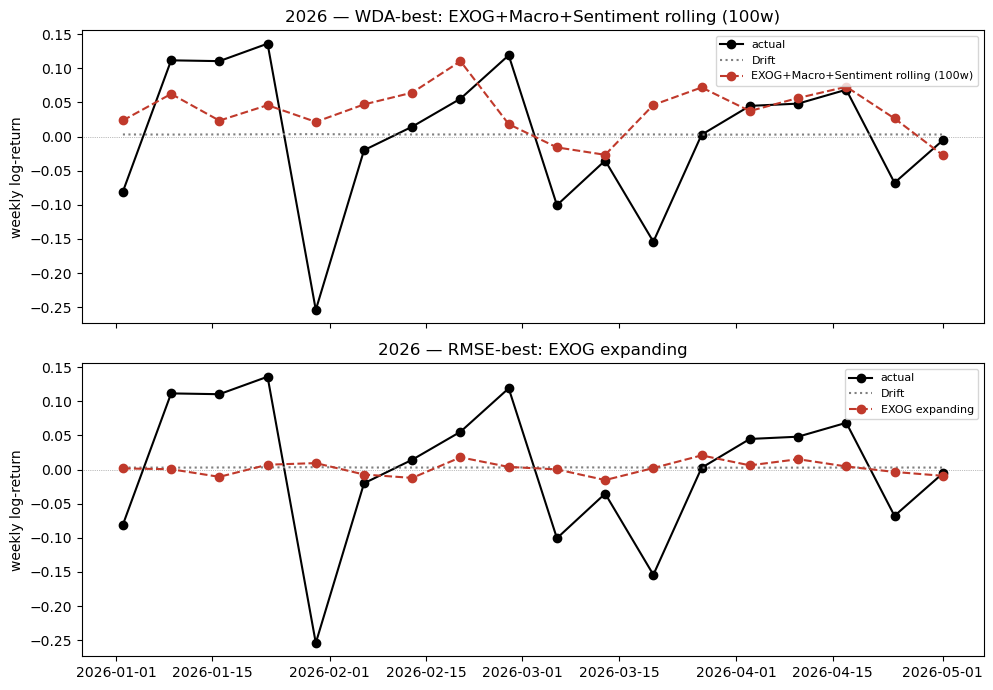

In [ ]:
m26 = dates_te >= pd.Timestamp('2026-01-01')
if m26.any():
    drift_p = all_preds['Drift (prevailing mean)']
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    for ax, (tag, bn) in zip(axes, [('WDA', best_wda), ('RMSE', best_rmse)]):
        bp = np.asarray(all_preds[bn])
        ax.axhline(0, color='grey', ls=':', lw=.5)
        ax.plot(dates_te[m26], np.asarray(y_te)[m26], 'k-o', label='actual')
        ax.plot(dates_te[m26], np.asarray(drift_p)[m26], ':', color='grey', label='Drift')
        ax.plot(dates_te[m26], bp[m26], '--o', color='#c0392b', label=bn)
        ax.set_title(f'2026 — {tag}-best: {bn}'); ax.set_ylabel('weekly log-return'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print('No 2026 data in test set yet.')


## 13. MIDAS Lag-Weight Profiles

This is the MIDAS analogue of feature importance. In the current run, the Stage 1 winner is a restricted MIDAS specification, so this section plots the fitted lag-weight profile for each monthly macro variable. The code also has a fallback for the U-MIDAS ablation: if U-MIDAS wins Stage 1, it reports one coefficient per monthly lag (3 per macro variable, since `N_MACRO_LAGS = 3`) instead of a smooth weight curve.


Lag-weight inspection variant: EXOG+Macro  |  fitted with 575 rows  |  Stage 1 spec: Beta-MIDAS


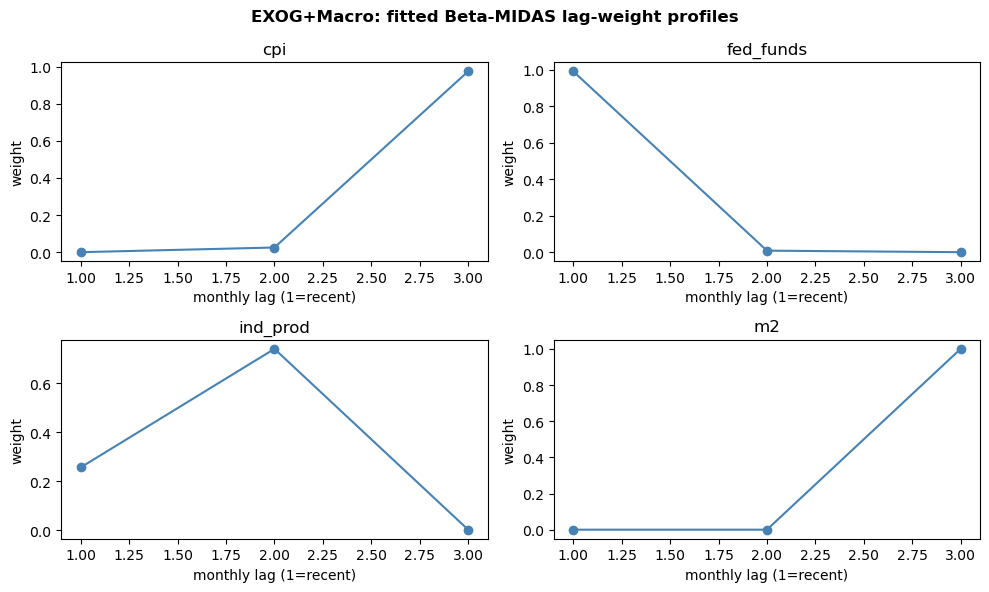

In [ ]:
# Refit the plain EXOG+Macro MIDAS model through the last test row for interpretation.
L = test_pos[-1] + 1
fit_macro = fit_dispatch(y_F[:L], base_F[:L], {v: macro_F[v][:L] for v in macro_F})
print(f'Lag-weight inspection variant: EXOG+Macro  |  fitted with {L} rows  |  Stage 1 spec: {best_spec}')

if fit_macro['spec'] == 'restricted':
    weights = fit_macro['weights']
    variables = list(weights)
    ncol = 2
    nrow = int(np.ceil(len(variables) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(10, 3 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, var in zip(axes, variables):
        w = weights[var]
        ax.plot(range(1, len(w) + 1), w, '-o', color='steelblue')
        ax.set_title(var)
        ax.set_xlabel('monthly lag (1=recent)')
        ax.set_ylabel('weight')
    for ax in axes[len(variables):]:
        ax.axis('off')
    fig.suptitle(f'EXOG+Macro: fitted {best_spec} lag-weight profiles', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    n_base_cols = 1 + base_F.shape[1]
    macro_coefs = fit_macro['coefs'][n_base_cols:]
    names = [f'{v}_mlag{k}' for v in fit_macro['names'] for k in range(1, fit_macro['ncols'][v] + 1)]
    coef_table = pd.DataFrame({'macro_lag': names, 'coef': macro_coefs})
    print('U-MIDAS macro coefficients:')
    print(coef_table.round(6).to_string(index=False))
